In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{'chignolin': {np.float64(0.3): [np.float64(759431.8004269999), np.float64(500376348.40299195), np.float64(214486218.151836), np.float64(155178.49113), np.float64(70246286.231424), np.float64(2377651.279575), np.float64(4798143.98184), np.float64(7612945.147305), np.float64(8405631.65411), np.float64(1227451.48398), np.float64(10227270.213108), np.float64(72798746.96196), np.float64(9969643.038608), np.float64(75254469.858078), np.float64(369411830.355891), np.float64(215157153.48505998), np.float64(6872236.723678), np.float64(120171.616799), np.float64(477806406.03274804), np.float64(4708.484085), np.float64(564544374.508826), np.float64(2854514.6834380003), np.float64(3877727.412042), np.float64(109105518.518472), np.float64(9183441.374146001), np.float64(752156.947458), np.float64(11272307.557364), np.float64(7327033436.490052), np.float64(14714801.929585), np.float64(16727788856.99953), np.float64(2878206585.844954), np.float64(181752.17862), np.float64(30673714.390574), np.float64

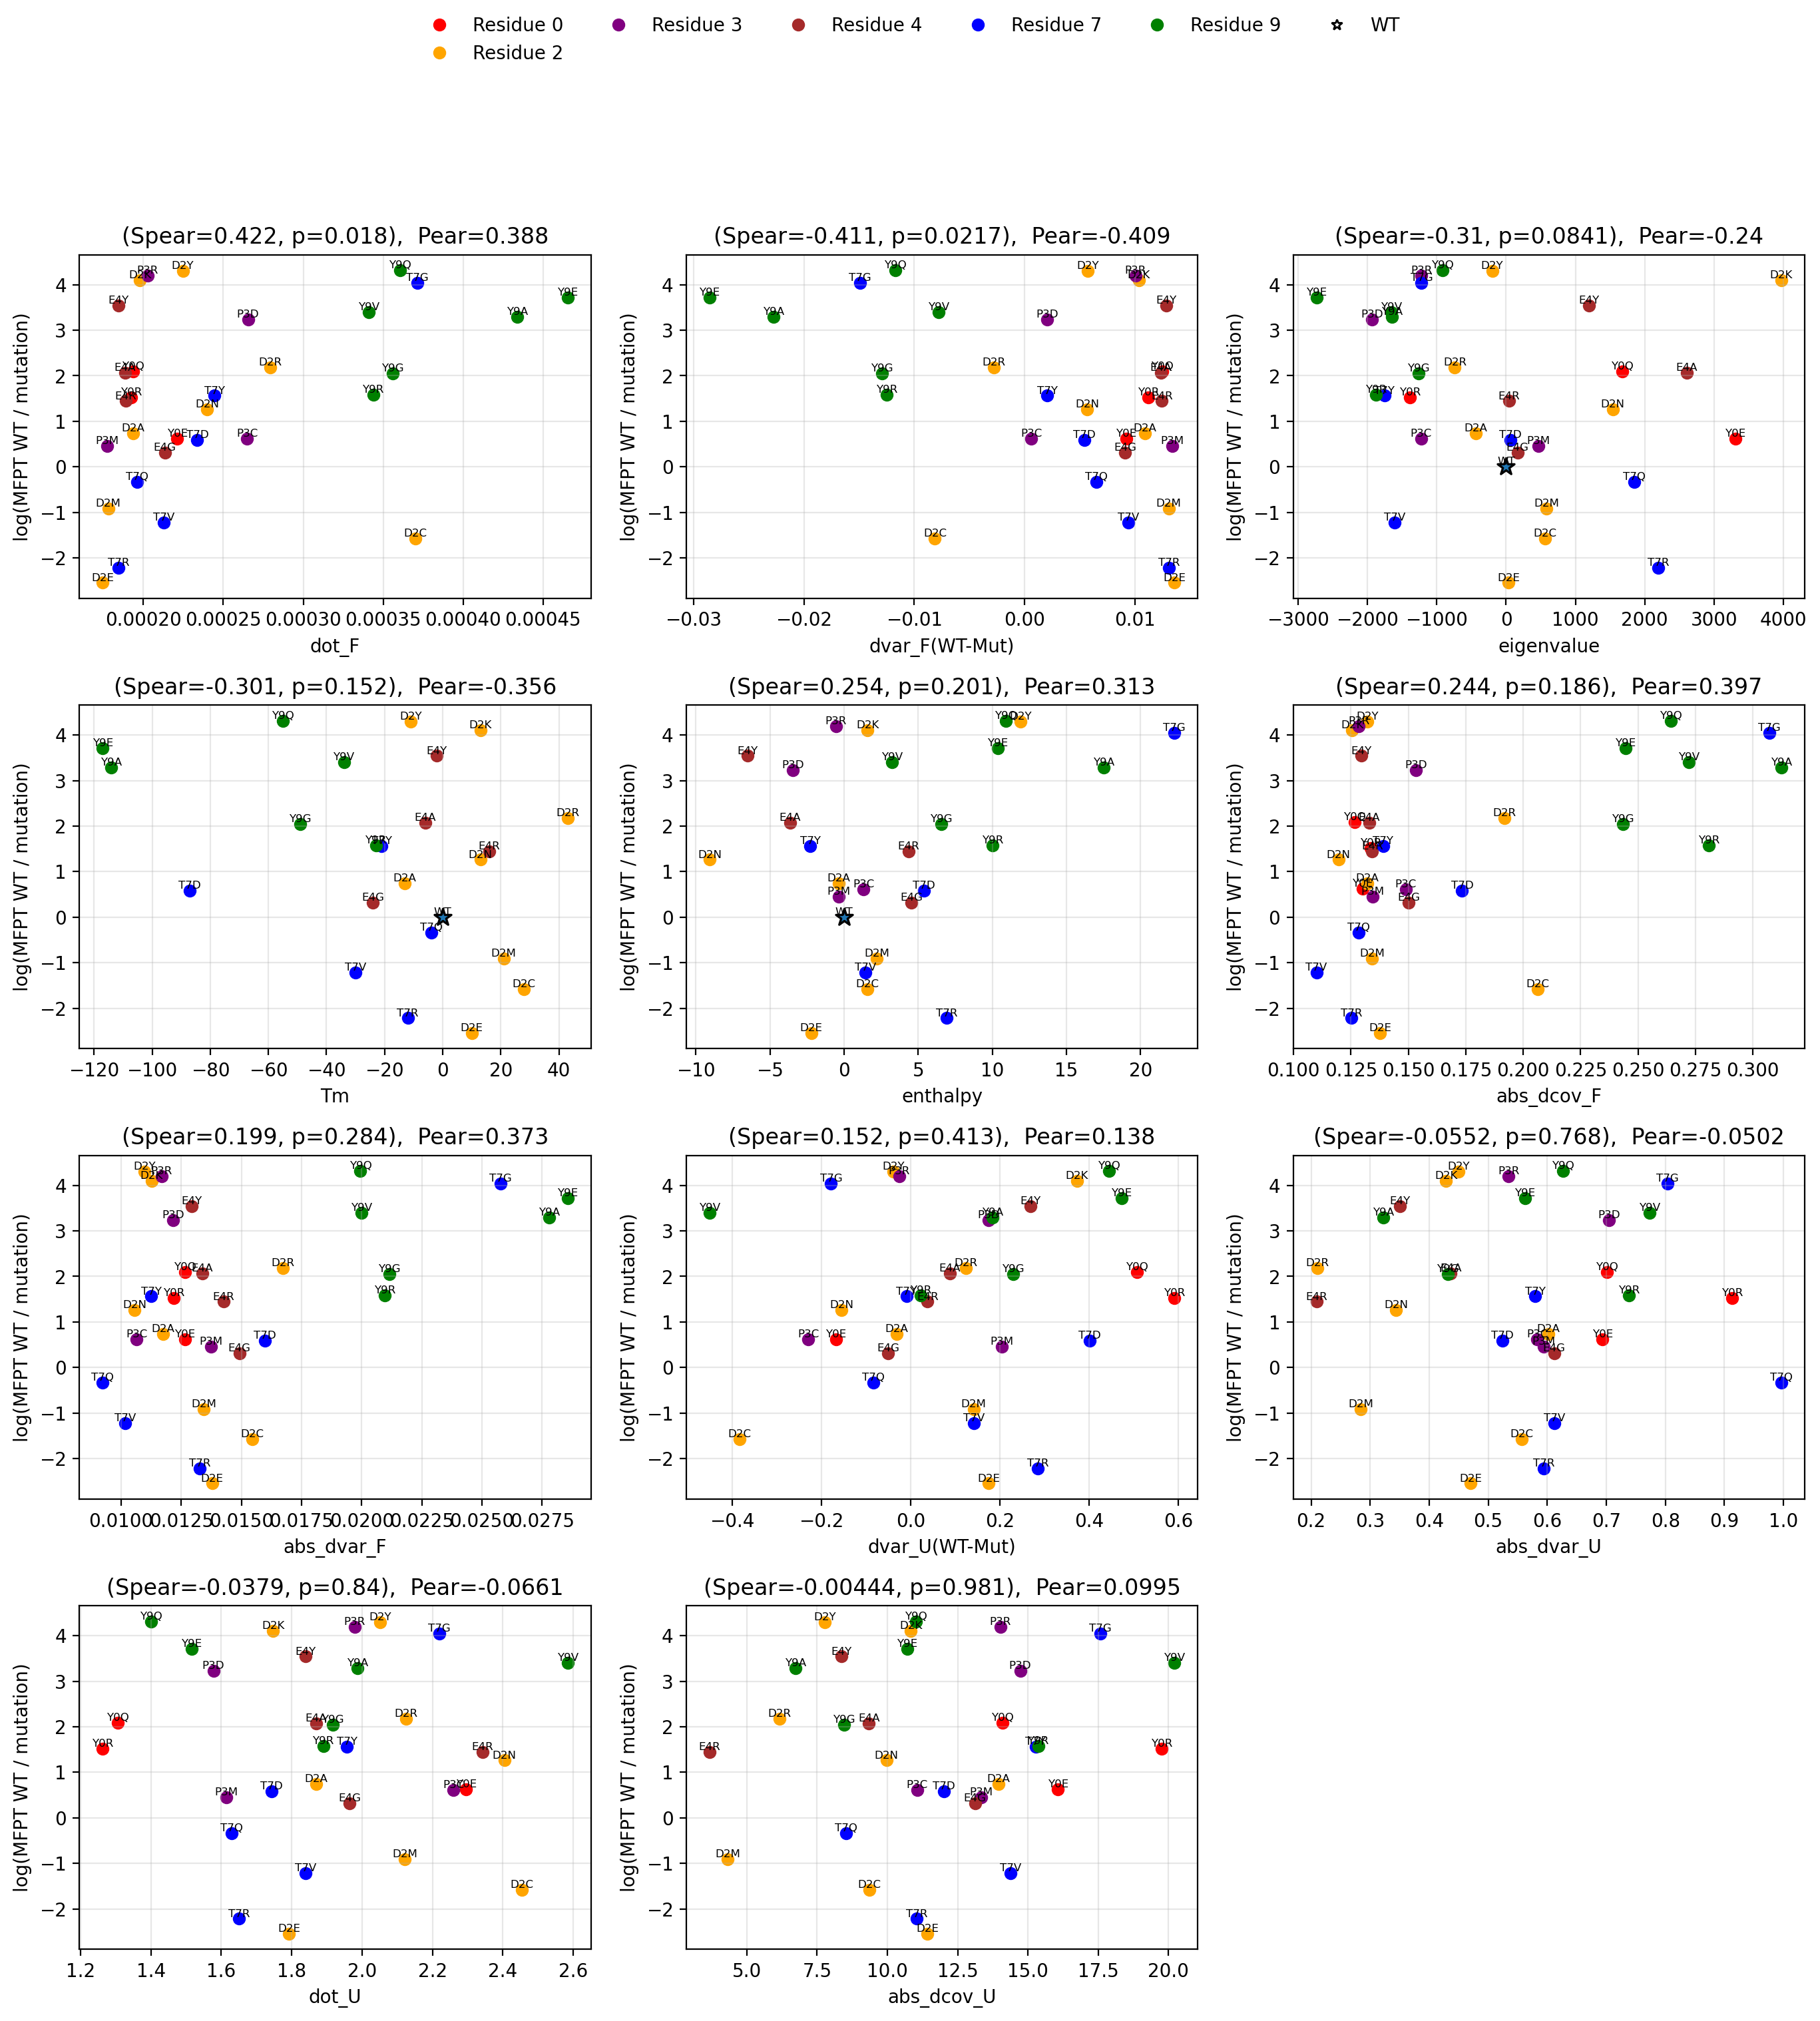

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
import pickle
from common.consts import res_colors
from common.utils import collect_df, collect_df_best_p

def ratio_or_raw(wt, arr, prop_name):
    if pd.isna(wt):
        return arr
    return wt - arr if prop_name != 'tm' else np.array(wt - arr) 

def plot_mfpt_corr_grid(
    df: pd.DataFrame,
    prop_cols,
    ncols=3
):
    wt_label = 'WT'
    group_col = 'residue_idx'
    res_keys = sorted(int(k) for k in df[group_col].dropna().unique())

    wt_mfpt = float(df.loc['WT', 'mfpt'])
    y_all = np.log(wt_mfpt / df['mfpt'].to_numpy())
    names = df.index.to_numpy()
    wt_star = dict(s=90, marker='*', edgecolors='k', linewidths=1.2, zorder=3)

    x_cache = {}
    mask_cache = {}
    corr = {}

    for prop_col in prop_cols:
        wt_prop = df.loc[wt_label, prop_col]
        x_all = df[prop_col].to_numpy()

        if not pd.isna(wt_prop):
            x_all = x_all - wt_prop

        mask = np.isfinite(x_all) & np.isfinite(y_all)
        x_cache[prop_col] = x_all
        mask_cache[prop_col] = mask

        pearson_r, _ = stats.pearsonr(x_all[mask], y_all[mask])
        spearman_r, p = stats.spearmanr(x_all[mask], y_all[mask])
        corr[prop_col] = (spearman_r, p, pearson_r)

    ordered = sorted(prop_cols, key=lambda p: abs(corr[p][0]), reverse=True)
    n = len(ordered)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.8 * nrows), squeeze=False, dpi=200)

    for idx, prop_col in enumerate(ordered):
        ax = axes[idx // ncols][idx % ncols]
        x_all = x_cache[prop_col]
        mask = mask_cache[prop_col]
        wt_prop = df.loc[wt_label, prop_col]

        if not pd.isna(wt_prop):
            ax.scatter(0, 0, **wt_star)

        for k in res_keys:
            sel = (df[group_col].to_numpy() == k)
            ax.scatter(x_all[sel], y_all[sel], c=res_colors.get(k))

        for xv, yv, name, m in zip(x_all, y_all, names, mask):
            if m:
                ax.text(xv, yv, name, fontsize=6, ha='center', va='bottom')

        spearman_r,p, pearson_r  = corr[prop_col]
        ax.set_xlabel(prop_col)
        ax.set_ylabel('log(MFPT WT / mutation)')
        ax.set_title(f"(Spear={spearman_r:.3g}, p={p:.3g}),  Pear={pearson_r:.3g}")
        ax.grid(True, alpha=0.3)

    for j in range(n, nrows * ncols):
        fig.delaxes(axes[j // ncols][j % ncols])

    handles = [Line2D([0], [0], marker='o', linestyle='', color=res_colors[k], label=f"Residue {k}") for k in res_keys]
    handles.append(Line2D([0], [0], marker='*', linestyle='', color='w', markeredgecolor='k', label=wt_label))
    fig.legend(handles=handles, loc='upper center', ncol=min(len(handles), 6), frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()
    return corr

props = [
    "eigenvalue", "Tm", "enthalpy", "dvar_F(WT-Mut)", "dvar_U(WT-Mut)", "abs_dvar_F",  "abs_dvar_U", "dot_F", "dot_U", "abs_dcov_F", "abs_dcov_U"
]

with open("../data/mfpt-pace=25000-new-ref.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

print(all_mfpt)
thresholds = np.sort(np.array(list(all_mfpt['chignolin'].keys()), dtype=float))
    
print(thresholds[2])
df = collect_df(False, all_mfpt, thresholds[1])
# df = collect_df_best_p(False, all_mfpt, thresholds)
stats_map = plot_mfpt_corr_grid(df, props)



chignolin
chignolin (WT): 1.819 us, extra: 8
YYAPETGTWY
YYAPETGTWY (D2A): 0.8682 us, extra: 16
YYCPETGTWY
YYCPETGTWY (D2C): 8.836 us, extra: 9
YYMPETGTWY
YYMPETGTWY (D2M): 4.52 us, extra: 37
YYNPETGTWY
YYNPETGTWY (D2N): 0.5151 us, extra: 12
YYRPETGTWY
YYRPETGTWY (D2R): 0.206 us, extra: 6
YYEPETGTWY
YYEPETGTWY (D2E): 23.23 us, extra: 24
YYDPETGTWE
YYDPETGTWE (Y9E): 0.04428 us, extra: 5
YYDPETGTWG
YYDPETGTWG (Y9G): 0.2351 us, extra: 31
YYDPETGTWQ
YYDPETGTWQ (Y9Q): 0.02433 us, extra: 10
YYDPETGTWR
YYDPETGTWR (Y9R): 0.3754 us, extra: 16
YYDPETGTWV
YYDPETGTWV (Y9V): 0.06089 us, extra: 11
YYDPETGTWA
YYDPETGTWA (Y9A): 0.06766 us, extra: 44
YYDPETGVWY
YYDPETGVWY (T7V): 6.144 us, extra: 19
YYDPETGQWY
YYDPETGQWY (T7Q): 2.544 us, extra: 5
YYDPETGRWY
YYDPETGRWY (T7R): 16.71 us, extra: 9
YYDPETGYWY
YYDPETGYWY (T7Y): 0.3816 us, extra: 10
YYDPETGGWY
YYDPETGGWY (T7G): 0.03187 us, extra: 14
YYDPETGDWY
YYDPETGDWY (T7D): 1.011 us, extra: 5
RYDPETGTWY
RYDPETGTWY (Y0R): 0.3976 us, extra: 22
QYDPETGTWY
QYDP

/tmp/ipykernel_3674004/845913542.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corr_df, x=group_col, y='Spearman_r',



Per-residue correlation summary:
   residue_idx  Pearson_r  Spearman_r
3            9  -0.480259   -0.600000
2            7  -0.355949   -0.300000
0            2  -0.242543   -0.119763
1            4   0.385117    0.400000


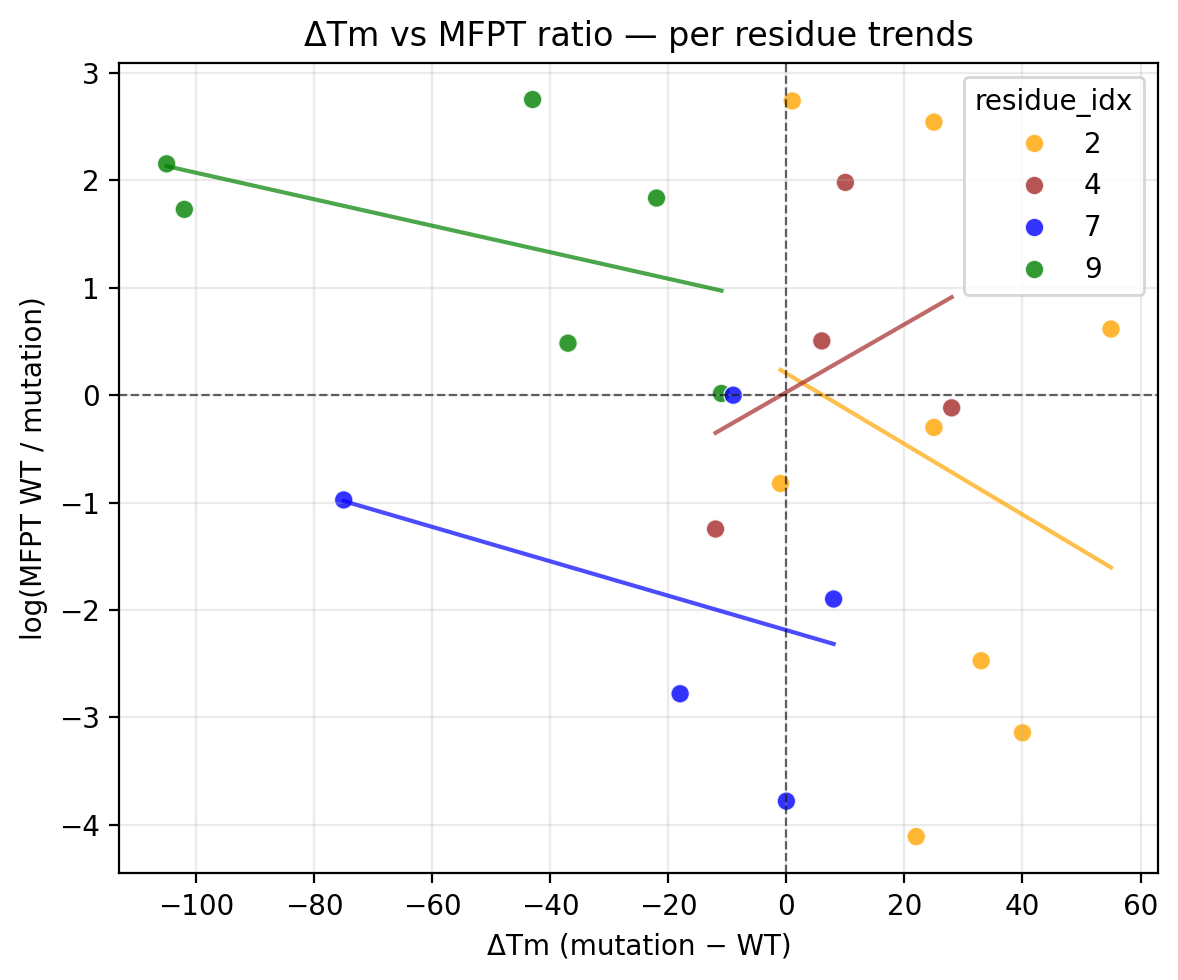

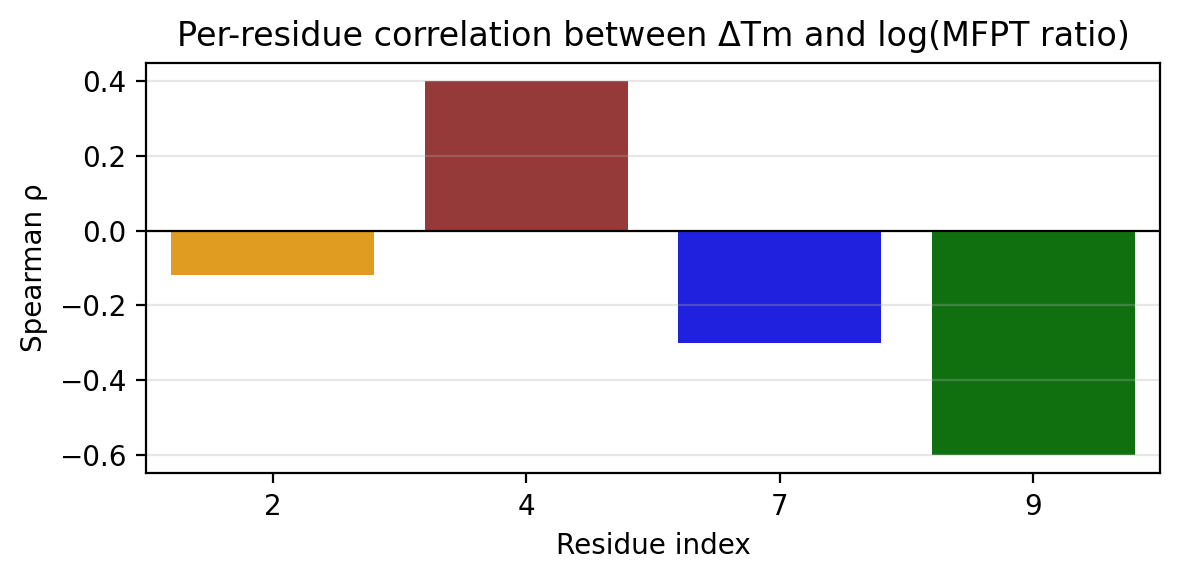

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pickle
from common.consts import res_colors
from common.utils import collect_df

def plot_delta_tm_vs_mfpt(df, group_col='residue_idx', tm_col='Tm', mfpt_col='mfpt', wt_label='WT', res_colors=None):
    df = df.copy()
    df = df[df[group_col].notna()]
    df[tm_col] = pd.to_numeric(df[tm_col], errors='coerce')
    df[mfpt_col] = pd.to_numeric(df[mfpt_col], errors='coerce')
    df = df.dropna(subset=[group_col, tm_col, mfpt_col])

    # Ensure residue_idx is integer-like for consistency
    df[group_col] = df[group_col].astype(float).astype(int)

    # ΔTm and log(MFPT WT / mut)
    wt_tm = float(df.loc[wt_label, tm_col]) if wt_label in df.index else float(df[tm_col].median())
    wt_mfpt = float(df.loc[wt_label, mfpt_col]) if wt_label in df.index else float(df[mfpt_col].median())
    df['dTm'] = df[tm_col] - wt_tm
    df['log_ratio'] = np.log(wt_mfpt / df[mfpt_col])

    # Build palette safely
    unique_res = sorted(df[group_col].unique())
    if res_colors is not None:
        # Convert keys to int to match df
        palette = {int(k): v for k, v in res_colors.items() if int(k) in unique_res}
    else:
        palette = sns.color_palette("tab10", n_colors=len(unique_res))
        palette = {r: palette[i % len(palette)] for i, r in enumerate(unique_res)}

    # ===== Scatter plot with regression per residue =====
    fig, ax = plt.subplots(figsize=(6,5), dpi=200)
    sns.scatterplot(
        data=df,
        x='dTm', y='log_ratio',
        hue=group_col, palette=palette,
        s=45, alpha=0.8, ax=ax
    )

    # Regression lines per residue
    for ridx, sub in df.groupby(group_col):
        if len(sub) > 2:
            slope, intercept, r, p, _ = stats.linregress(sub['dTm'], sub['log_ratio'])
            xs = np.linspace(sub['dTm'].min(), sub['dTm'].max(), 50)
            ax.plot(xs, slope*xs + intercept, color=palette.get(int(ridx), 'gray'), lw=1.5, alpha=0.7)

    ax.axvline(0, color='k', lw=0.8, ls='--', alpha=0.6)
    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.6)
    ax.set_xlabel('ΔTm (mutation − WT)')
    ax.set_ylabel('log(MFPT WT / mutation)')
    ax.set_title('ΔTm vs MFPT ratio — per residue trends')
    ax.grid(True, alpha=0.25)
    plt.tight_layout()

    # ===== Per-residue correlation summary =====
    corr_data = []
    for ridx, sub in df.groupby(group_col):
        if sub['dTm'].nunique() > 1 and sub['log_ratio'].nunique() > 1:
            pear, _ = stats.pearsonr(sub['dTm'], sub['log_ratio'])
            spear, _ = stats.spearmanr(sub['dTm'], sub['log_ratio'])
            corr_data.append((ridx, pear, spear))
    corr_df = pd.DataFrame(corr_data, columns=[group_col, 'Pearson_r', 'Spearman_r'])

    fig2, ax2 = plt.subplots(figsize=(6,3), dpi=200)
    sns.barplot(data=corr_df, x=group_col, y='Spearman_r',
                palette=[palette.get(int(r), 'gray') for r in corr_df[group_col]], ax=ax2)
    ax2.axhline(0, color='k', lw=0.8)
    ax2.set_title('Per-residue correlation between ΔTm and log(MFPT ratio)')
    ax2.set_ylabel('Spearman ρ')
    ax2.set_xlabel('Residue index')
    ax2.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()

    return df, corr_df

# =====================================================
# Load data and run
# =====================================================
if __name__ == "__main__":
    with open("../data/mfpt-pace=25000-new-ref.pkl", "rb") as f:
        all_mfpt = pickle.load(f)

    thresholds = np.sort(np.array(list(all_mfpt['chignolin'].keys()), dtype=float))
    df = collect_df(False, all_mfpt, thresholds[1])

    df_out, corr_df = plot_delta_tm_vs_mfpt(df, res_colors=res_colors)
    print("\nPer-residue correlation summary:")
    print(corr_df.sort_values('Spearman_r'))


In [14]:
blosum62 = {
    ("D", "A"): -2, ("A", "D"): -2,
    ("D", "C"): -3, ("C", "D"): -3,
    ("D", "M"): -3, ("M", "D"): -3,
    ("D", "N"):  1, ("N", "D"):  1,
    ("D", "R"): -2, ("R", "D"): -2,
    ("D", "E"):  2, ("E", "D"):  2,
    ("Y", "E"): -2, ("E", "Y"): -2,
    ("Y", "G"): -3, ("G", "Y"): -3,
    ("Y", "Q"): -1, ("Q", "Y"): -1,
    ("Y", "R"): -2, ("R", "Y"): -2,
    ("Y", "V"): -1, ("V", "Y"): -1,
    ("Y", "A"): -2, ("A", "Y"): -2,
    ("T", "V"):  0, ("V", "T"):  0,
    ("T", "Q"): -1, ("Q", "T"): -1,
    ("T", "R"): -1, ("R", "T"): -1,
    ("T", "Y"): -2, ("Y", "T"): -2,
    ("T", "G"): -2, ("G", "T"): -2,
    ("T", "D"): -1, ("D", "T"): -1,
}
grantham = {
    ("D", "A"): 126, ("A", "D"): 126,
    ("D", "C"): 154, ("C", "D"): 154,
    ("D", "M"): 160, ("M", "D"): 160,
    ("D", "N"):  23, ("N", "D"):  23,
    ("D", "R"):  96, ("R", "D"):  96,
    ("D", "E"):  45, ("E", "D"):  45,
    ("Y", "E"): 122, ("E", "Y"): 122,
    ("Y", "G"): 147, ("G", "Y"): 147,
    ("Y", "Q"): 143, ("Q", "Y"): 143,
    ("Y", "R"):  77, ("R", "Y"):  77,
    ("Y", "V"):  32, ("V", "Y"):  32,
    ("Y", "A"):  107, ("A", "Y"): 107,
    ("T", "V"):  69, ("V", "T"):  69,
    ("T", "Q"):  42, ("Q", "T"):  42,
    ("T", "R"):  71, ("R", "T"):  71,
    ("T", "Y"):  92, ("Y", "T"):  92,
    ("T", "G"):  59, ("G", "T"):  59,
    ("T", "D"):  65, ("D", "T"):  65,
}

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from common.consts import proteins, long_to_short

from scipy import stats

from common.utils import estimateMFPT

def parse_short(s):
    return s[0], s[-1]

def compute_mfpt(long_name, th):
    s = np.sort(np.array(all_mfpt[long_name][th], float))
    mfpt, _ = estimateMFPT(s, 10)
    return float(mfpt)

def gather(proteins, mutation_map, th):
    xb, xg, y, labels = [], [], [], []
    wt_mfpt = compute_mfpt('chignolin', th)
    for long_name in proteins:
        short = mutation_map.get(long_name)
        if not short:
            continue
        a, b = parse_short(short)
        if (a, b) not in blosum62 or (a, b) not in grantham:
            continue
        mfpt = compute_mfpt(long_name, th)
        if not np.isfinite(mfpt) or mfpt <= 0:
            continue
        xb.append(float(blosum62[(a, b)]))
        xg.append(float(grantham[(a, b)]))
        y.append(mfpt)
        labels.append(short)
    return np.array(xb), np.array(xg), np.array(y), labels

def scatter_fit(ax, x, y, labels, title, xlabel):
    ax.scatter(x, y)
    for xi, yi, lab in zip(x, y, labels):
        ax.text(xi, yi, lab, fontsize=8, ha="right", va="bottom")

    if len(x) >= 2:
        r, p = stats.pearsonr(x, y)
        ax.set_title(f"{title}\nr={r:.2f}, p={p:.2g}")
    else:
        ax.set_title(title)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("log(MFPT(WT / Mut))")

def plot_correlations_over(proteins, mutation_map, th):
    xb, xg, y, labels = gather(proteins, mutation_map, th)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    scatter_fit(axes[0], xb, y, labels, "BLOSUM62 vs log(MFPT)", "BLOSUM62 (orig→mut)")
    scatter_fit(axes[1], xg, y, labels, "Grantham vs log(MFPT)", "Grantham distance (orig→mut)")
    plt.tight_layout()
    plt.show()
    return {"labels": labels, "blosum": xb, "grantham": xg, "log_mfpt": y}

# Example usage
th = thresholds[5]
res = plot_correlations_over(proteins[:-1], long_to_short, th)


IndexError: single positional indexer is out-of-bounds

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def corr_vector(df, features, target_log_ratio=True):
    wt_mfpt = float(df.loc['WT','mfpt'])
    y = np.log(wt_mfpt / df['mfpt'].to_numpy()) if target_log_ratio else df['mfpt'].to_numpy()
    cors = []
    for f in features:
        x = df[f].to_numpy(dtype=float)
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() >= 3 and np.std(x[m]) > 1e-12 and np.std(y[m]) > 1e-12:
            r, _ = stats.pearsonr(x[m], y[m])
        else:
            r = np.nan
        cors.append(np.abs(r))
    return np.array(cors, float)

def plot_corr_bar_and_heatmap(df, features):
    cors = corr_vector(df, features, target_log_ratio=True)

    fig, axes = plt.subplots(2, 1, figsize=(max(8, 0.6*len(features)), 6), constrained_layout=True)

    ax = axes[0]
    ax.barh(features, np.nan_to_num(cors, nan=0.0))
    ax.axvline(0, lw=1, color='k')
    ax.set_xlabel("Pearson r with log(WT/Mut MFPT)")
    for i, r in enumerate(cors):
        if np.isfinite(r):
            ax.text(r, i, f"{r:.2f}", va='center', ha='left' if r>=0 else 'right', fontsize=8)

    ax = axes[1]
    H = np.nan_to_num(cors, nan=0.0)[None, :]
    im = ax.imshow(H, aspect='auto', vmin=0, vmax=1, cmap='coolwarm')
    ax.set_yticks([0])
    ax.set_yticklabels(["corr(y)"])
    ax.set_xticks(np.arange(len(features)))
    ax.set_xticklabels(features, rotation=90, fontsize=8)
    for j, r in enumerate(cors):
        txt = "NA" if not np.isfinite(r) else f"{r:.2f}"
        ax.text(j, 0, txt, ha='center', va='center', fontsize=8, color='black')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Absolute Pearson r (vmin=0, vmax=1)")

    plt.show()

# Example:
features = [
    "cos_sim_F", "cos_sim_U", "avg_change_diff", "eigenvalue", "dvar_F(WT-Mut)",  "dvar_U(WT-Mut)", "abs_dvar_F"
    #  "avg_change_F", "avg_change_U", "abs_dvar_F", "abs_dvar_U",
]
plot_corr_bar_and_heatmap(df, features)

KeyError: 'cos_sim_F'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import normalized_mutual_info_score
from pgmpy.estimators import HillClimbSearch, ExpertKnowledge, MaximumLikelihoodEstimator
from pgmpy.models import LinearGaussianBayesianNetwork
from networkx.drawing.nx_agraph import graphviz_layout

def _bin_series(s):
    n_bins = 3
    s = pd.Series(s).astype(float)

    return pd.qcut(s, q=n_bins, labels=[f"q{i+1}" for i in range(n_bins)], duplicates="drop")



def discretize_df(df, cols):
    out = df.copy()
    for c in cols:
        out[c] = _bin_series(out[c])
    return out

def learn_discrete_bn(df, draw=True):
    # wt_mfpt = float(df.loc["Wildtype", "mfpt"])
    # dfb = df.copy()
    # if "Wildtype" in dfb.index:
    #     dfb = dfb.drop("Wildtype")

    features = [
    "cos_sim_F", "cos_sim_U", "avg_change_diff", "eigenvalue", "dvar_F(WT-Mut)",  "dvar_U(WT-Mut)", "abs_dvar_F"
    #  "avg_change_F", "avg_change_U", "abs_dvar_F", "abs_dvar_U",
]
    # df = df[features].dropna()
    df['mfpt'] = df['mfpt'].astype(float) * 1e-6  
    nodes = list(df.columns)

    ek = ExpertKnowledge(
        forbidden_edges=[("mfpt", v) for v in nodes if v != "mfpt"]
    )

    est = HillClimbSearch(df)
    best = est.estimate(scoring_method="ll-g", expert_knowledge=ek, max_indegree=3)
    model = LinearGaussianBayesianNetwork(best.edges())
    model.fit(df)

    G = nx.DiGraph(model.edges())
    plt.figure(figsize=(9, 7))

    from networkx.drawing.nx_agraph import graphviz_layout
    pos = graphviz_layout(G, prog="dot")

    nx.draw(
        G, pos,
        with_labels=True,
        node_color="#cfe8ff",
        node_size=2200,
        font_size=7,
        arrowsize=18
    )
    plt.tight_layout()
    plt.show()
  
 

    return model

bn_model = learn_discrete_bn(df, draw=True)


KeyError: 'mfpt'

In [ ]:
from sklearn.feature_selection import mutual_info_regression

features = [
        "eigenvalue","full_evec_dot","cos_sim_folded","cos_sim_unfolded",
        "avg_change_diff","diagonal_cov_dot_unfolded",
        "abs_dvar_folded","avg_change_folded","avg_change_unfolded",
        "abs_dvar_unfolded"
    ]
X = df[features].to_numpy()
y = df["mfpt"].to_numpy()

mi = mutual_info_regression(X, y, random_state=0)

# pair variable names with MI values
mi_scores = dict(zip(features, mi))
print(mi_scores)

ValueError: Input X contains NaN.

/tmp/ipykernel_2805851/60863814.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_2805851/60863814.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_2805851/60863814.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_2805851/60863814.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, delim_whitespace=True, commen

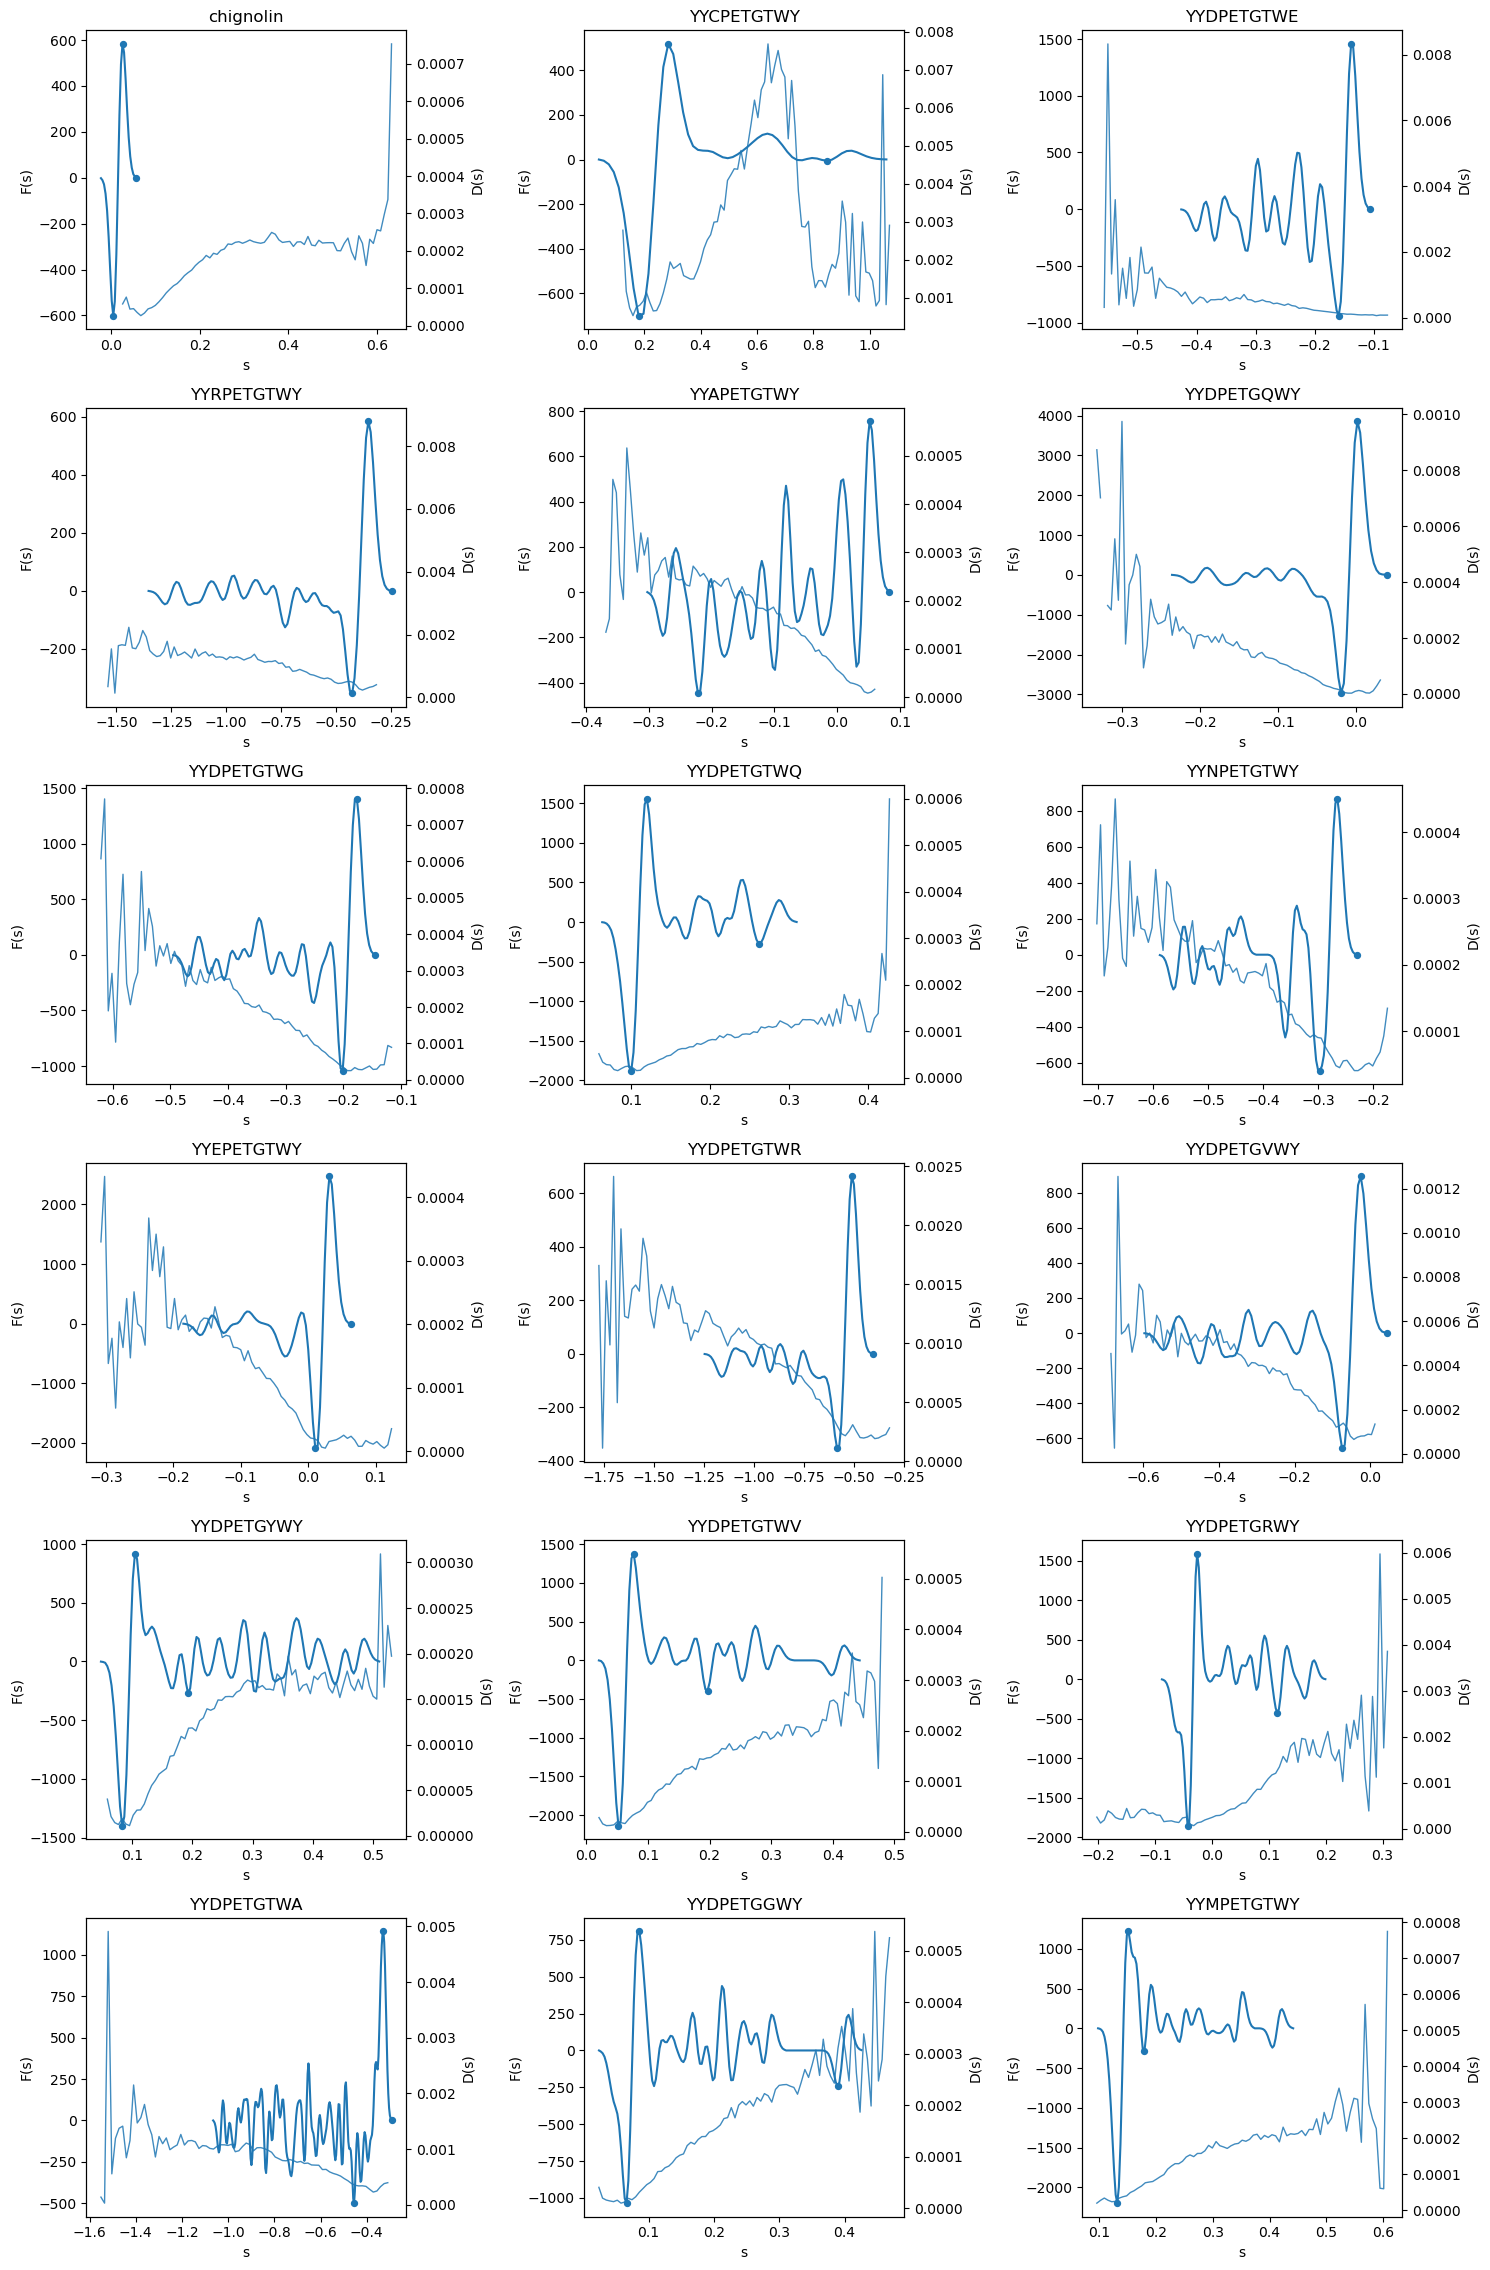

In [ ]:
# import subprocess
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from common.consts import proteins

# cv_col = "HLDA"
# runs = range(4000, 4050)
# bins_diff = 80
# lag = 1

# def sum_hills(hills, out):
#     out.parent.mkdir(parents=True, exist_ok=True)
#     subprocess.run(["plumed","sum_hills","--hills",str(hills),"--mintozero","--outfile",str(out)], check=True, stdout=subprocess.DEVNULL)

# def read_fes(path):
#     df = pd.read_csv(path, delim_whitespace=True, comment="#", header=None)
#     if df.shape[1] == 2:
#         df.columns = ["s","F"]
#     else:
#         df.columns = [f"c{i}" for i in range(df.shape[1])]
#         df = df.rename(columns={df.columns[0]:"s", df.columns[-1]:"F"})[["s","F"]]
#     return df.sort_values("s").reset_index(drop=True)

# def read_colvar_with_fields(path):
#     with open(path, "r") as f:
#         header = f.readline().strip()
#     names = header.split()[2:]
#     return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

# def get_cv_column(df):
#     if cv_col in df.columns: return cv_col
#     low = {c.lower(): c for c in df.columns}
#     return low[cv_col.lower()]

# def estimate_D_of_s(colvar_paths, nbins=bins_diff, lag=lag):
#     edges = None
#     num = None
#     cnt = None
#     for p in colvar_paths:
#         df = read_colvar_with_fields(p)
#         cvc = get_cv_column(df)
#         s = df[cvc].to_numpy()
#         t = df["time"].to_numpy()
#         if edges is None:
#             edges = np.linspace(np.min(s), np.max(s), nbins + 1)
#             num = np.zeros(nbins, dtype=float)
#             cnt = np.zeros(nbins, dtype=int)
#         else:
#             smin = min(edges[0], np.min(s))
#             smax = max(edges[-1], np.max(s))
#             edges = np.linspace(smin, smax, nbins + 1)
#         idx = np.digitize(s, edges) - 1
#         ds = s[lag:] - s[:-lag]
#         dt_local = t[lag:] - t[:-lag]
#         vals = (ds * ds) / (2.0 * dt_local)
#         idx0 = idx[:-lag]
#         for k in range(nbins):
#             m = (idx0 == k)
#             if m.any():
#                 num[k] += np.sum(vals[m])
#                 cnt[k] += int(m.sum())
#     centers = 0.5 * (edges[:-1] + edges[1:])
#     D = np.full(nbins, np.nan)
#     ok = cnt > 0
#     D[ok] = num[ok] / cnt[ok]
#     return centers, D, cnt

# def left_min_max_right(fes):
#     F = fes["F"].to_numpy(); s = fes["s"].to_numpy()
#     imax = int(np.argmax(F))
#     ileft = int(np.argmin(F[:imax])) if imax > 0 else 0
#     iright = int(np.argmin(F[imax+1:]) + imax + 1) if imax < len(F) - 1 else len(F) - 1
#     return (s[ileft], F[ileft]), (s[imax], F[imax]), (s[iright], F[iright])

# def analyze_protein(p, runs):
#     base = Path("../data") / p / "output"
#     rep = runs.start
#     rdir = base / f"run_{rep}"
#     hills = rdir / f"HILLS_HLDA_{rep}"
#     fes_path = rdir / f"fes_HLDA_{rep}.dat"
#     sum_hills(hills, fes_path)
#     fes = read_fes(fes_path)
#     a, m, b = left_min_max_right(fes)
#     colvars = [base / f"run_{i}" / f"HLDA_COLVAR_{i}" for i in runs]
#     sgrid, D, N = estimate_D_of_s(colvars)
#     return dict(p=p, fes=fes, a=a, m=m, b=b, sgrid=sgrid, D=D, N=N)

# def plot_grid(per_row=3):
#     results = [analyze_protein(p, runs) for p in proteins]
#     n = len(results)
#     rows = (n + per_row - 1) // per_row
#     fig, axes = plt.subplots(rows, per_row, figsize=(per_row * 5.0, rows * 3.8), squeeze=False)
#     for ax in axes.ravel(): ax.axis("off")
#     for ax, r in zip(axes.ravel(), results):
#         ax.axis("on")
#         fes = r["fes"]; a, m, b = r["a"], r["m"], r["b"]
#         ax.plot(fes["s"], fes["F"], lw=1.5)
#         ax.scatter([a[0], m[0], b[0]], [a[1], m[1], b[1]], s=18)
#         ax.set_xlabel("s"); ax.set_ylabel("F(s)")
#         ax2 = ax.twinx()
#         ax2.plot(r["sgrid"], r["D"], lw=1.0, alpha=0.85)
#         ax2.set_ylabel("D(s)")
#         ax.set_title(f"{r['p']}")
#     plt.tight_layout()
#     plt.show()

# plot_grid(per_row=3)
